# *In silico* predictions at subcellular resolution

Scores the trained model on the seqFISH+ test cells and reconstructs transcript profiles from it,
by running `seqfish/evaluate.py` and `seqfish/postprocess.py`.

Data — set `SVC_DATA_ROOT` to the directory holding the seqFISH+ files (default: `../../../data`).
They are available on Zenodo: <https://doi.org/10.5281/zenodo.22693727>

- `test_seqfish.npz`, `train_seqfish.npz`, `gene_names.txt`, `gene2vec_weight_seqfish.npy`
- `cell_mask_contour_preprocessed.pkl`, `nuclear_mask_contour_preprocessed.pkl` — cell and nuclear
  boundary points, used to draw the predictions in the original section
- `seqfish_data_dict.pkl` — the measured transcripts, drawn alongside the predictions

Checkpoint — unpack `checkpoints.zip` from the same deposit into `../../../checkpoints`

Written

- `eval_results.npy`, `prediction_mu.npz`, `prediction_r.npz` — by `seqfish/evaluate.py`
- `predicted_transcripts.csv` — by `seqfish/postprocess.py`

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, to_rgba

SVC_ROOT = Path(os.environ.get('SVC_ROOT', '../../..'))   # github.com/aster-ww/SVC
sys.path.insert(0, str(SVC_ROOT))
from svc.postprocess import expand_transcripts

DATA_ROOT = Path(os.environ.get('SVC_DATA_ROOT', '../../../data'))
DATA_DIR = DATA_ROOT / 'seqfish'
CKPT_DIR = Path('../../../checkpoints')
OUT_DIR = Path('../../../output/seqfish')

## Cross-validated prediction

`evaluate.py` splits the 1,000 genes into 20 folds. Each fold's genes are masked in every test cell
and predicted from the remaining genes, the cell and nuclear morphology images and the neighbor
context, so no gene is ever predicted from itself. With `--save-predictions` the predicted negative
binomial parameters of every gene are written out.

In [2]:
!python {SVC_ROOT}/seqfish/evaluate.py --data-root {DATA_ROOT} --ckpt-dir {CKPT_DIR} --save-predictions

checkpoint: ../../../checkpoints/checkpoint_seqFISH.pth
[seqfish] Test cells: 14, Genes: 1000
  Building test kNN (k_max=4, K_SCALES=(4,), batch-aware) ...
  built kNN: N=14, k=4, batches=1, short=0
  tau_per_scale_test=['578.45']
  Loaded ckpt from epoch 363, tau_per_scale=[578.44580078125], cell_median_train=16758.000
  wrote ../../../checkpoints/prediction_mu.npz / prediction_r.npz
  PCC=0.3305, RMSE=0.3267, Cos=0.4260, CellPCC=0.4625, CellRMSE=7.3307, CellCos=0.9048, CrossGenePCC=0.8670, CrossGeneRMSE=10.2581, Dist=0.8990

Results saved to ../../../checkpoints/eval_results.npy


In [3]:
results = np.load(CKPT_DIR / 'eval_results.npy', allow_pickle=True).item()
for key in ['pcc', 'rmse', 'cosine']:
    print(f"{key:8s} subcellular {results['mean_' + key]:7.4f} (median {results['median_' + key]:7.4f})"
          f"   cell-level {results['cell_mean_' + key]:7.4f} (median {results['cell_median_' + key]:7.4f})")
print(f"cross-gene pcc {results['cross_gene_pcc']:.4f}, rmse {results['cross_gene_rmse']:.4f}")
print(f"distance to nuclear center pcc {results['dist_center_pcc']:.4f}")

pcc      subcellular  0.3305 (median  0.3140)   cell-level  0.4625 (median  0.4979)
rmse     subcellular  0.3267 (median  0.2833)   cell-level  7.3307 (median  5.1177)
cosine   subcellular  0.4260 (median  0.4051)   cell-level  0.9048 (median  0.9240)
cross-gene pcc 0.8670, rmse 10.2581
distance to nuclear center pcc 0.8990


## Cell-level expression

Each gene's total count per cell, averaged over the test cells.

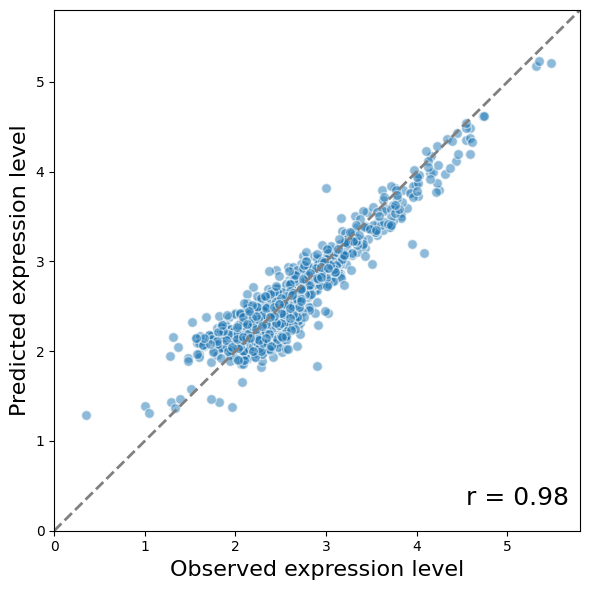

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log1p(results['truth_gene_mean']), np.log1p(results['pred_gene_mean']),
           s=50, alpha=0.5, edgecolors='white')
ax.plot([0, 6], [0, 6], '--', lw=2, color='gray')
ax.set_xlim(0, 5.8)
ax.set_ylim(0, 5.8)
ax.set_xlabel('Observed expression level', fontsize=16)
ax.set_ylabel('Predicted expression level', fontsize=16)
r = np.corrcoef(results['truth_gene_mean'], results['pred_gene_mean'])[0, 1]
ax.text(0.98, 0.05, f'r = {r:.2f}', transform=ax.transAxes, ha='right', fontsize=18)
plt.tight_layout()
plt.show()

## Distance to the nuclear center

The 49 seqFISH+ genes with an annotated localization, as a count-weighted mean distance from the
nuclear center on the 12x12 registered polar grid, averaged over the cells in which the gene has at
least five measured transcripts.

In [5]:
protrusion_genes = ['Cyb5r3', 'Sh3pxd2a', 'Ddr2', 'Kif1c', 'Kctd10',
                    'Dynll2', 'Arhgap11a', 'Dync1li2', 'Palld', 'Naa50']
nuclear_genes = ['Col1a1', 'Fn1', 'Fbln2', 'Col6a2', 'Bgn',
                 'Nid1', 'Lox', 'P4hb', 'Aebp1', 'Emp1',
                 'Col5a1', 'Sdc4', 'Postn', 'Col3a1', 'Pdia6',
                 'Col5a2', 'Itgb1', 'Calu', 'Pdia3']
cytoplasm_genes = ['Ddb1', 'Myh9', 'Actn1', 'Tagln2', 'Kpnb1',
                   'Hnrnpf', 'Ppp1ca', 'Hnrnpl', 'Pcbp1', 'Tagln',
                   'Fscn1', 'Psat1', 'Cald1', 'Snd1', 'Uba1',
                   'Hnrnpm', 'Cap1', 'Ssrp1', 'Ugdh', 'Caprin1']
REPRESENTATIVE = ['Nid1', 'Pdia6', 'Hnrnpf', 'Palld', 'Cyb5r3']

gene_names = np.loadtxt(DATA_DIR / 'gene_names.txt', dtype=str).tolist()
test = np.load(DATA_DIR / 'test_seqfish.npz', allow_pickle=True)
truth = test['data_ori']
test_cell_names = test['cell_names']
prediction = np.load(CKPT_DIR / 'prediction_mu.npz')['prediction']

selected_gene = protrusion_genes + nuclear_genes + cytoplasm_genes
selected_idx = [gene_names.index(g) for g in selected_gene]
gene_type = np.array(['Protrusion' if g in protrusion_genes else
                      'Cytoplasm' if g in cytoplasm_genes else 'Nuclear/Perinuclear'
                      for g in selected_gene])

_ii, _jj = np.meshgrid(np.arange(12), np.arange(12), indexing='ij')
D = np.sqrt((_ii + 0.5 - 6) ** 2 + (_jj + 0.5 - 6) ** 2) / 6

def distance_ratio(img):
    total = img.sum(axis=(-1, -2))
    r = np.where(total != 0, (img * D).sum(axis=(-1, -2)) / np.where(total == 0, 1, total), 0.0)
    return np.where(total != 0, np.minimum(r, 1.0), 0.0)

valid = truth[:, selected_idx].sum(axis=(-1, -2)) >= 5
real_dist = (distance_ratio(truth[:, selected_idx]) * valid).sum(0) / valid.sum(0)
pred_dist = (distance_ratio(prediction[:, selected_idx]) * valid).sum(0) / valid.sum(0)
print('(cell, gene) images kept: %d / %d' % (valid.sum(), valid.size))

(cell, gene) images kept: 671 / 686


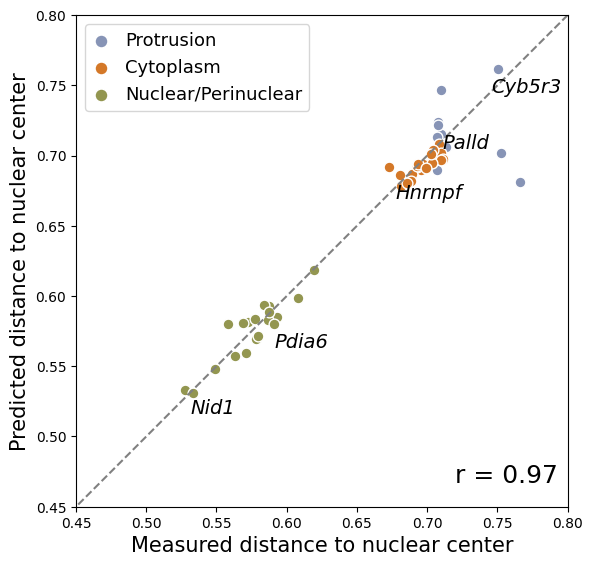

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
for color, atype in zip(['#8794b6', '#d47828', '#939650'],
                        ['Protrusion', 'Cytoplasm', 'Nuclear/Perinuclear']):
    s = gene_type == atype
    ax.scatter(real_dist[s], pred_dist[s], c=color, s=60, label=atype, edgecolor='white')
ax.legend(fontsize=13, markerscale=1.2, handlelength=1)
for gene in REPRESENTATIVE:
    k = selected_gene.index(gene)
    ax.annotate(gene, (real_dist[k] + 0.02, pred_dist[k] - 0.001), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=14, fontstyle='italic')
ax.plot([0, 0.8], [0, 0.8], '--', color='gray')
ax.set_aspect('equal')
ax.set_xlim(0.45, 0.8)
ax.set_ylim(0.45, 0.8)
ax.set_xlabel('Measured distance to nuclear center', fontsize=15)
ax.set_ylabel('Predicted distance to nuclear center', fontsize=15)
ax.text(0.98, 0.05, f'r = {np.corrcoef(real_dist, pred_dist)[0, 1]:.2f}',
        transform=ax.transAxes, ha='right', fontsize=18)
plt.tight_layout()
plt.show()

## Subcellular pattern of individual genes

Measured and predicted 12x12 maps of one test cell, on a shared color scale per gene.

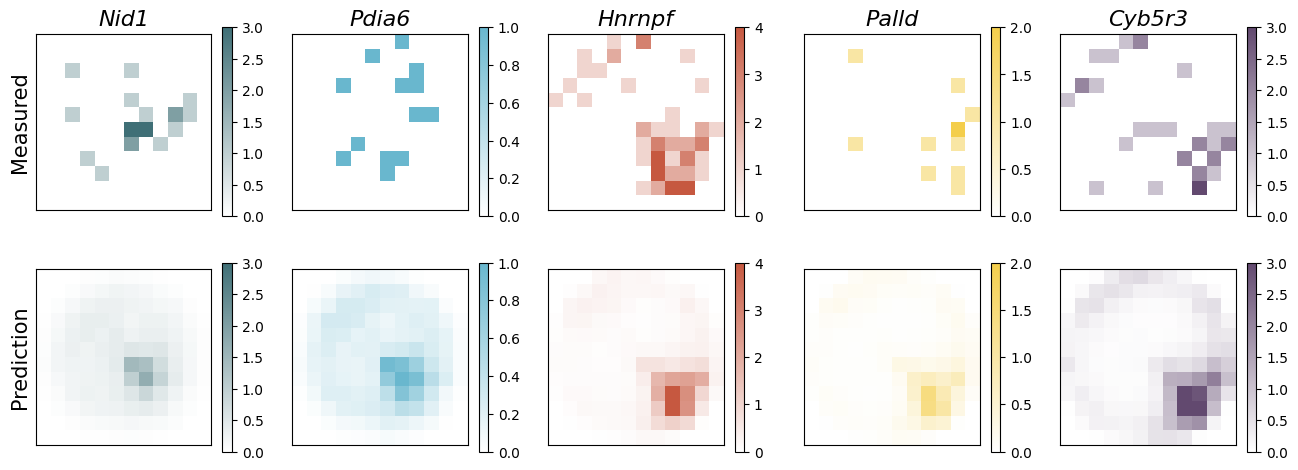

In [7]:
CELL = '16-3'
cell_idx = list(test_cell_names).index(CELL)
colors = ['#3f6f76', '#69b7ce', '#c65840', '#f4ce4b', '#62496f']

fig, axes = plt.subplots(2, 5, figsize=(13, 5.2))
for i, (gene, color) in enumerate(zip(REPRESENTATIVE, colors)):
    cmap = LinearSegmentedColormap.from_list(gene, [(1, 1, 1), to_rgba(color)])
    g = gene_names.index(gene)
    vmax = truth[cell_idx, g].max()
    for row, image in enumerate([truth[cell_idx, g], prediction[cell_idx, g]]):
        im = axes[row, i].imshow(image, cmap=cmap, vmin=0, vmax=vmax, origin='lower')
        plt.colorbar(im, ax=axes[row, i], shrink=0.75)
        axes[row, i].set_xticks([])
        axes[row, i].set_yticks([])
    axes[0, i].set_title(gene, fontsize=16, fontstyle='italic')
axes[0, 0].set_ylabel('Measured', fontsize=15)
axes[1, 0].set_ylabel('Prediction', fontsize=15)
plt.tight_layout()
plt.show()

## Back to the original section

`postprocess.py` samples transcript counts from the predicted negative binomial parameters on a
48x48 grid, reads off each transcript's radial position and angle, and maps it onto the cell's own
contour at the same angle, giving coordinates in the frame of the original section.

In [8]:
!python {SVC_ROOT}/seqfish/postprocess.py --data-root {DATA_ROOT} --pred-dir {CKPT_DIR} --out {OUT_DIR}/predicted_transcripts.csv --genes Nid1 Pdia6 Hnrnpf Palld Cyb5r3

predictions (14, 1000, 12, 12)
reconstructing 5 gene(s)
100%|█████████████████████████████████████████| 14/14 [00:00<00:00, 1243.68it/s]
sampled 3,511 transcripts
100%|███████████████████████████████████████████| 14/14 [00:00<00:00, 21.57it/s]
saved ../../../output/seqfish/predicted_transcripts.csv


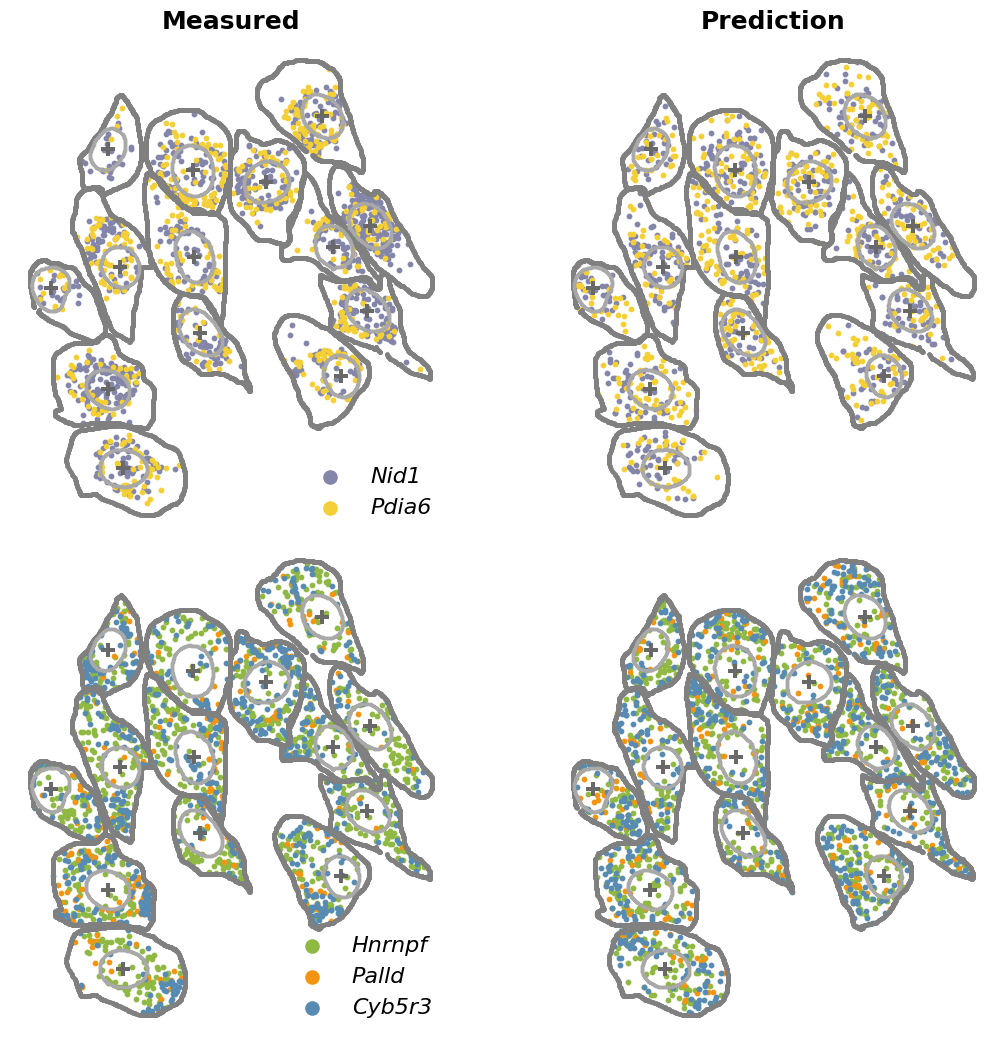

In [9]:
predicted = expand_transcripts(pd.read_csv(OUT_DIR / 'predicted_transcripts.csv'))
measured = pd.read_pickle(DATA_DIR / 'seqfish_data_dict.pkl')['data_df']
measured = measured[measured.cell.isin(test_cell_names)]
cell_contour = pd.read_pickle(DATA_DIR / 'cell_mask_contour_preprocessed.pkl')
cell_contour = cell_contour[cell_contour.cell.isin(test_cell_names)]
nuclear_contour = pd.read_pickle(DATA_DIR / 'nuclear_mask_contour_preprocessed.pkl')
nuclear_contour = nuclear_contour[nuclear_contour.cell.isin(test_cell_names)]

def draw(ax, df, genes, colors, xcol, ycol, title, legend):
    ax.scatter(cell_contour.x, cell_contour.y, color='grey', s=6, zorder=20)
    ax.scatter(nuclear_contour.x, nuclear_contour.y, color='darkgrey', s=2, alpha=0.6, zorder=20)
    ax.scatter(nuclear_contour.centerX, nuclear_contour.centerY,
               marker='+', color='dimgray', s=100, zorder=20)
    for gene, color in zip(genes, colors):
        sub = df[df.gene == gene]
        ax.scatter(sub[xcol], sub[ycol], s=10, color=color, label=gene)
    if legend:
        for text in ax.legend(fontsize=16, markerscale=3, frameon=False).get_texts():
            text.set_fontstyle('italic')
    if title:
        ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')

fig, axes = plt.subplots(2, 2, figsize=(14, 13), gridspec_kw={'hspace': 0., 'wspace': 0.})
for row, (genes, colors) in enumerate([(['Nid1', 'Pdia6'], ['#8386a8', '#f5cf36']),
                                       (['Hnrnpf', 'Palld', 'Cyb5r3'],
                                        ['#8fb943', '#f49512', '#578bb2'])]):
    draw(axes[row, 0], measured, genes, colors, 'x', 'y', 'Measured' if row == 0 else None, True)
    draw(axes[row, 1], predicted, genes, colors, 'x_original', 'y_original',
         'Prediction' if row == 0 else None, False)
plt.show()